# CMAPSS Dataset - Comprehensive Data Analysis

## Objective
Comprehensive exploratory analysis of all 4 subsets of the NASA CMAPSS dataset (FD001-FD004):

- **Data quality checks**: NaN, missing values, duplicates
- **Temporal analysis**: Sequences, gaps, inconsistencies
- **Descriptive statistics**: Sensors, RUL, lifecycle lengths
- **Operating distribution**: Conditions and fault modes
- **Visualizations**: Degradation patterns, sensor behavior

In [65]:
# Import libraries
import sys
import warnings
warnings.filterwarnings('ignore')

sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_ingestion.data_loader import CMAPSSDataLoader

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("Libraries imported successfully")

Libraries imported successfully


## 1. Dataset Loading

In [66]:
# Initialize data loader
loader = CMAPSSDataLoader(data_dir='../data/raw')

# Load all training subsets
train_data = loader.load_all_subsets(data_type='train')

print("Datasets loaded:")
for subset_name, df in train_data.items():
    print(f"  - {subset_name}: {len(df)} rows, {df['unit'].nunique()} engines")

Datasets loaded:
  - FD001: 20631 rows, 100 engines
  - FD002: 53759 rows, 260 engines
  - FD003: 24720 rows, 100 engines
  - FD004: 61249 rows, 249 engines


In [67]:
# Dataset info
dataset_info = loader.get_dataset_info()

print("\nDataset Characteristics:\n")
for subset, info in dataset_info.items():
    print(f"{subset}:")
    print(f"  Operating Conditions: {info['conditions']}")
    print(f"  Fault Modes: {info['fault_modes']}")
    print(f"  Train Trajectories: {info['train_trajectories']}")
    print(f"  Test Trajectories: {info['test_trajectories']}")
    print()


Dataset Characteristics:

FD001:
  Operating Conditions: ONE (Sea Level)
  Fault Modes: ONE (HPC Degradation)
  Train Trajectories: 100
  Test Trajectories: 100

FD002:
  Operating Conditions: SIX
  Fault Modes: ONE (HPC Degradation)
  Train Trajectories: 260
  Test Trajectories: 259

FD003:
  Operating Conditions: ONE (Sea Level)
  Fault Modes: TWO (HPC Degradation, Fan Degradation)
  Train Trajectories: 100
  Test Trajectories: 100

FD004:
  Operating Conditions: SIX
  Fault Modes: TWO (HPC Degradation, Fan Degradation)
  Train Trajectories: 248
  Test Trajectories: 249



## 2. Data Quality Analysis

### 2.1 NaN and Missing Values Check

In [68]:
def analyze_missing_data(data_dict):
    """
    Analyze missing values across all datasets.
    """
    results = {}
    
    for subset_name, df in data_dict.items():
        total_cells = df.shape[0] * df.shape[1]
        missing_cells = df.isnull().sum().sum()
        missing_pct = (missing_cells / total_cells) * 100
        
        # Columns with missing values
        cols_with_missing = df.columns[df.isnull().any()].tolist()
        
        results[subset_name] = {
            'total_cells': total_cells,
            'missing_cells': missing_cells,
            'missing_pct': missing_pct,
            'cols_with_missing': cols_with_missing
        }
    
    return results

missing_analysis = analyze_missing_data(train_data)

print("MISSING VALUES ANALYSIS (NaN)\n")
print("=" * 70)
for subset, result in missing_analysis.items():
    print(f"\n{subset}:")
    print(f"  Total cells: {result['total_cells']:,}")
    print(f"  Missing cells: {result['missing_cells']}")
    print(f"  Missing percentage: {result['missing_pct']:.4f}%")
    
    if result['cols_with_missing']:
        print(f"  WARNING: Columns with NaN: {result['cols_with_missing']}")
    else:
        print("  No missing values")

print("\n" + "=" * 70)

MISSING VALUES ANALYSIS (NaN)


FD001:
  Total cells: 557,037
  Missing cells: 0
  Missing percentage: 0.0000%
  No missing values

FD002:
  Total cells: 1,451,493
  Missing cells: 0
  Missing percentage: 0.0000%
  No missing values

FD003:
  Total cells: 667,440
  Missing cells: 0
  Missing percentage: 0.0000%
  No missing values

FD004:
  Total cells: 1,653,723
  Missing cells: 0
  Missing percentage: 0.0000%
  No missing values



### 2.2 Duplicate Check

In [69]:
def analyze_duplicates(data_dict):
    """
    Check for duplicate rows.
    """
    results = {}
    
    for subset_name, df in data_dict.items():
        # Full duplicates
        full_duplicates = df.duplicated().sum()
        
        # Duplicates on (unit, time) - should not exist
        key_duplicates = df.duplicated(subset=['unit', 'time']).sum()
        
        results[subset_name] = {
            'full_duplicates': full_duplicates,
            'key_duplicates': key_duplicates
        }
    
    return results

duplicate_analysis = analyze_duplicates(train_data)

print("DUPLICATES ANALYSIS\n")
print("=" * 70)
for subset, result in duplicate_analysis.items():
    print(f"\n{subset}:")
    print(f"  Full duplicate rows: {result['full_duplicates']}")
    print(f"  Duplicates on (unit, time): {result['key_duplicates']}")
    
    if result['key_duplicates'] > 0:
        print("  WARNING: Duplicates found on primary key!")
    else:
        print("  No duplicates on (unit, time) key")

print("\n" + "=" * 70)

DUPLICATES ANALYSIS


FD001:
  Full duplicate rows: 0
  Duplicates on (unit, time): 0
  No duplicates on (unit, time) key

FD002:
  Full duplicate rows: 0
  Duplicates on (unit, time): 0
  No duplicates on (unit, time) key

FD003:
  Full duplicate rows: 0
  Duplicates on (unit, time): 0
  No duplicates on (unit, time) key

FD004:
  Full duplicate rows: 0
  Duplicates on (unit, time): 0
  No duplicates on (unit, time) key



## 3. Temporal Analysis

### 3.1 Temporal Sequence Check

In [70]:
def analyze_temporal_consistency(data_dict):
    """
    Check temporal consistency:
    - Sequences start at 1
    - Unit increments (no gaps)
    - No temporal jumps
    """
    results = {}
    
    for subset_name, df in data_dict.items():
        issues = []
        
        for unit_id in df['unit'].unique():
            unit_data = df[df['unit'] == unit_id].sort_values('time')
            times = unit_data['time'].values
            
            # Check 1: Starts at 1
            if times[0] != 1:
                issues.append({
                    'unit': unit_id,
                    'issue': 'start_not_1',
                    'value': times[0]
                })
            
            # Check 2: Unit increments
            diffs = np.diff(times)
            if not np.all(diffs == 1):
                gap_indices = np.nonzero(diffs != 1)[0]
                issues.append({
                    'unit': unit_id,
                    'issue': 'temporal_gap',
                    'gaps': len(gap_indices),
                    'max_gap': diffs.max()
                })
        
        results[subset_name] = {
            'total_units': df['unit'].nunique(),
            'issues': issues,
            'clean_units': df['unit'].nunique() - len({i['unit'] for i in issues})
        }
    
    return results

temporal_analysis = analyze_temporal_consistency(train_data)

print("TEMPORAL CONSISTENCY ANALYSIS\n")
print("=" * 70)
for subset, result in temporal_analysis.items():
    print(f"\n{subset}:")
    print(f"  Total engines: {result['total_units']}")
    print(f"  Engines with clean sequences: {result['clean_units']}")
    print(f"  Engines with issues: {len(result['issues'])}")
    
    if result['issues']:
        print("\n  WARNINGS:")
        for issue in result['issues'][:5]:  # Show first 5
            print(f"     - Unit {issue['unit']}: {issue['issue']}")
        if len(result['issues']) > 5:
            print(f"     ... and {len(result['issues']) - 5} more issues")
    else:
        print("  All temporal sequences are consistent")

print("\n" + "=" * 70)

TEMPORAL CONSISTENCY ANALYSIS


FD001:
  Total engines: 100
  Engines with clean sequences: 100
  Engines with issues: 0
  All temporal sequences are consistent

FD002:
  Total engines: 260
  Engines with clean sequences: 260
  Engines with issues: 0
  All temporal sequences are consistent

FD003:
  Total engines: 100
  Engines with clean sequences: 100
  Engines with issues: 0
  All temporal sequences are consistent

FD004:
  Total engines: 249
  Engines with clean sequences: 249
  Engines with issues: 0
  All temporal sequences are consistent



### 3.2 Lifecycle Length Distribution

In [71]:
def analyze_lifecycle_lengths(data_dict):
    """
    Analyze the distribution of engine lifecycle lengths.
    """
    results = {}
    
    for subset_name, df in data_dict.items():
        lifecycle = df.groupby('unit')['time'].max()
        
        results[subset_name] = {
            'min': lifecycle.min(),
            'max': lifecycle.max(),
            'mean': lifecycle.mean(),
            'median': lifecycle.median(),
            'std': lifecycle.std(),
            'distribution': lifecycle
        }
    
    return results

lifecycle_analysis = analyze_lifecycle_lengths(train_data)

print("LIFECYCLE LENGTH DISTRIBUTION (per engine)\n")
print("=" * 70)
for subset, result in lifecycle_analysis.items():
    print(f"\n{subset}:")
    print(f"  Min cycles: {result['min']}")
    print(f"  Max cycles: {result['max']}")
    print(f"  Mean: {result['mean']:.2f}")
    print(f"  Median: {result['median']:.2f}")
    print(f"  Std dev: {result['std']:.2f}")

print("\n" + "=" * 70)

LIFECYCLE LENGTH DISTRIBUTION (per engine)


FD001:
  Min cycles: 128
  Max cycles: 362
  Mean: 206.31
  Median: 199.00
  Std dev: 46.34

FD002:
  Min cycles: 128
  Max cycles: 378
  Mean: 206.77
  Median: 199.00
  Std dev: 46.78

FD003:
  Min cycles: 145
  Max cycles: 525
  Mean: 247.20
  Median: 220.50
  Std dev: 86.48

FD004:
  Min cycles: 128
  Max cycles: 543
  Mean: 245.98
  Median: 234.00
  Std dev: 73.11



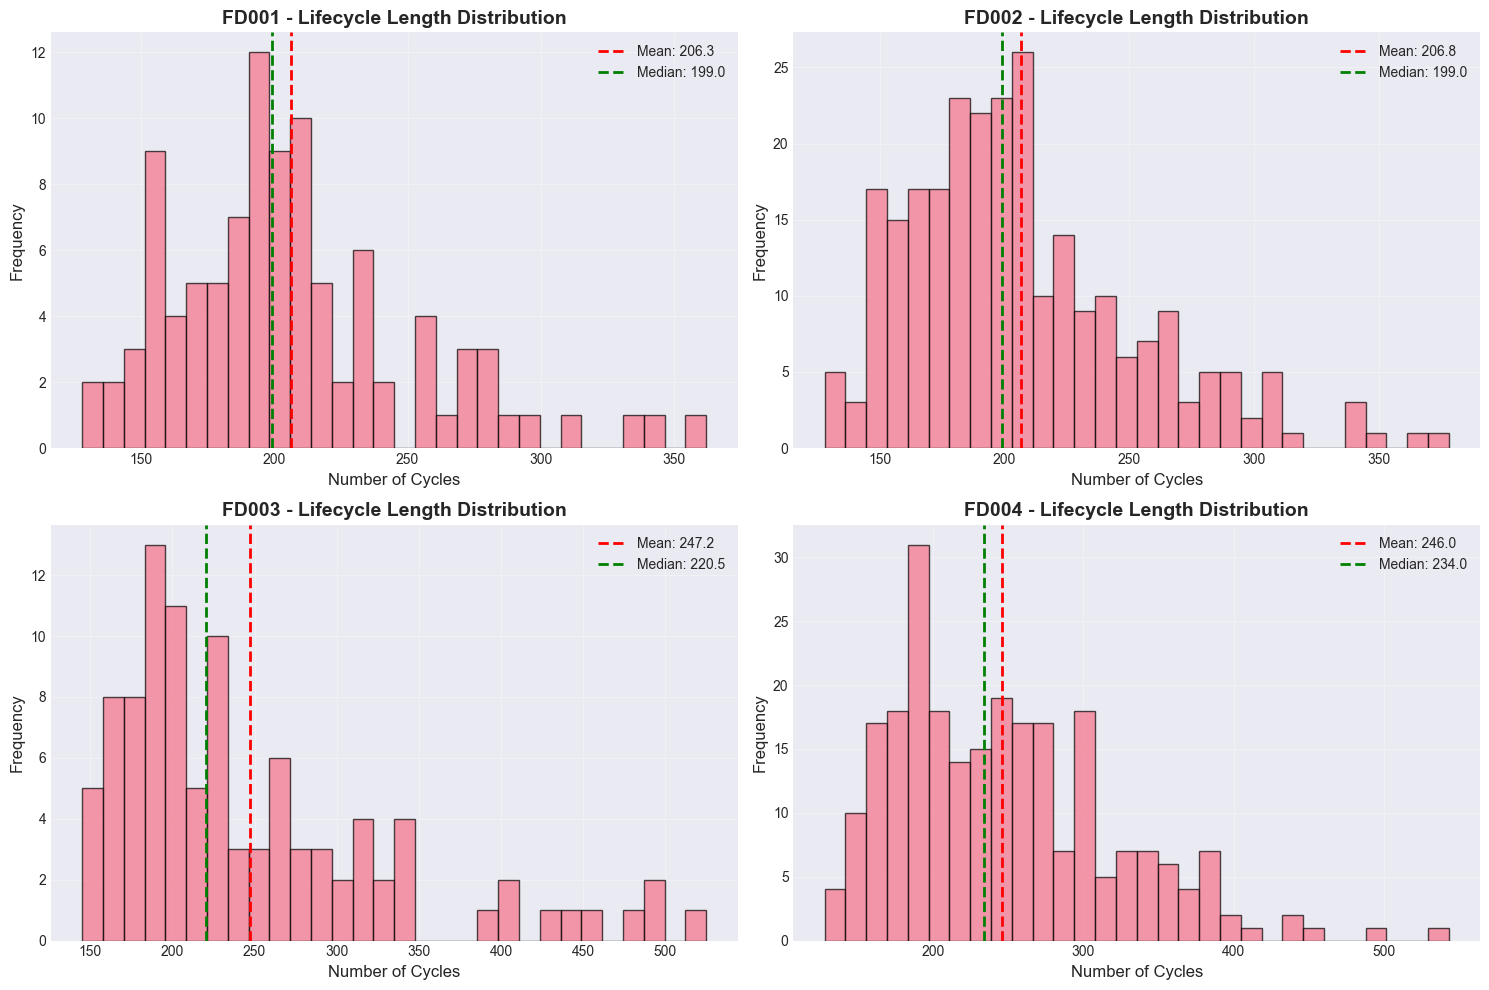

In [72]:
# Lifecycle length distribution plot
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (subset_name, result) in enumerate(lifecycle_analysis.items()):
    ax = axes[idx]
    
    result['distribution'].hist(bins=30, ax=ax, edgecolor='black', alpha=0.7)
    ax.axvline(result['mean'], color='red', linestyle='--', linewidth=2, label=f"Mean: {result['mean']:.1f}")
    ax.axvline(result['median'], color='green', linestyle='--', linewidth=2, label=f"Median: {result['median']:.1f}")
    
    ax.set_title(f"{subset_name} - Lifecycle Length Distribution", fontsize=14, fontweight='bold')
    ax.set_xlabel("Number of Cycles", fontsize=12)
    ax.set_ylabel("Frequency", fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Sensor Analysis

### 4.1 Sensor Descriptive Statistics

In [73]:
def analyze_sensor_statistics(data_dict):
    """
    Analyze sensor statistics and identify constant/uninformative sensors.
    """
    results = {}
    
    for subset_name, df in data_dict.items():
        sensor_cols = [col for col in df.columns if col.startswith('sensor_')]
        
        # Compute variance for each sensor
        sensor_stats = df[sensor_cols].describe().T
        sensor_stats['variance'] = df[sensor_cols].var()
        sensor_stats['zeros_pct'] = (df[sensor_cols] == 0).mean() * 100
        
        # Constant sensors (variance ~0)
        constant_sensors = sensor_stats[sensor_stats['variance'] < 1e-6].index.tolist()
        
        # Low-variance sensors
        low_variance_sensors = sensor_stats[
            (sensor_stats['variance'] < sensor_stats['variance'].quantile(0.1)) & 
            (sensor_stats['variance'] >= 1e-6)
        ].index.tolist()
        
        results[subset_name] = {
            'stats': sensor_stats,
            'constant_sensors': constant_sensors,
            'low_variance_sensors': low_variance_sensors,
            'total_sensors': len(sensor_cols)
        }
    
    return results

sensor_analysis = analyze_sensor_statistics(train_data)

print("SENSOR ANALYSIS\n")
print("=" * 70)
for subset, result in sensor_analysis.items():
    print(f"\n{subset}:")
    print(f"  Total sensors: {result['total_sensors']}")
    print(f"  Constant sensors (variance ≈ 0): {len(result['constant_sensors'])}")
    
    if result['constant_sensors']:
        print(f"    WARNING: {result['constant_sensors']}")
    
    print(f"  Low-variance sensors: {len(result['low_variance_sensors'])}")
    
    if result['low_variance_sensors']:
        print(f"    INFO: {result['low_variance_sensors']}")

print("\n" + "=" * 70)

SENSOR ANALYSIS


FD001:
  Total sensors: 21
  Constant sensors (variance ≈ 0): 6
  Low-variance sensors: 0

FD002:
  Total sensors: 21
  Constant sensors (variance ≈ 0): 0
  Low-variance sensors: 2
    INFO: ['sensor_10', 'sensor_16']

FD003:
  Total sensors: 21
  Constant sensors (variance ≈ 0): 5
  Low-variance sensors: 0

FD004:
  Total sensors: 21
  Constant sensors (variance ≈ 0): 0
  Low-variance sensors: 2
    INFO: ['sensor_10', 'sensor_16']



In [74]:
# Show detailed statistics for FD001
print("\nDETAILED SENSOR STATISTICS - FD001:\n")
pd.options.display.float_format = '{:.2f}'.format
print(sensor_analysis['FD001']['stats'][['mean', 'std', 'min', 'max', 'variance']].sort_values('variance', ascending=False))


DETAILED SENSOR STATISTICS - FD001:

             mean   std     min     max  variance
sensor_9  9065.24 22.08 9021.73 9244.59    487.65
sensor_14 8143.75 19.08 8099.94 8293.72    363.90
sensor_4  1408.93  9.00 1382.25 1441.49     81.01
sensor_3  1590.52  6.13 1571.04 1616.91     37.59
sensor_17  393.21  1.55  388.00  400.00      2.40
sensor_7   553.37  0.89  549.85  556.06      0.78
sensor_12  521.41  0.74  518.69  523.38      0.54
sensor_2   642.68  0.50  641.21  644.53      0.25
sensor_11   47.54  0.27   46.85   48.53      0.07
sensor_20   38.82  0.18   38.14   39.43      0.03
sensor_21   23.29  0.11   22.89   23.62      0.01
sensor_13 2388.10  0.07 2387.88 2388.56      0.01
sensor_8  2388.10  0.07 2387.90 2388.56      0.01
sensor_15    8.44  0.04    8.32    8.58      0.00
sensor_6    21.61  0.00   21.60   21.61      0.00
sensor_5    14.62  0.00   14.62   14.62      0.00
sensor_16    0.03  0.00    0.03    0.03      0.00
sensor_1   518.67  0.00  518.67  518.67      0.00
sensor_10   

### 4.2 Sensor Correlation

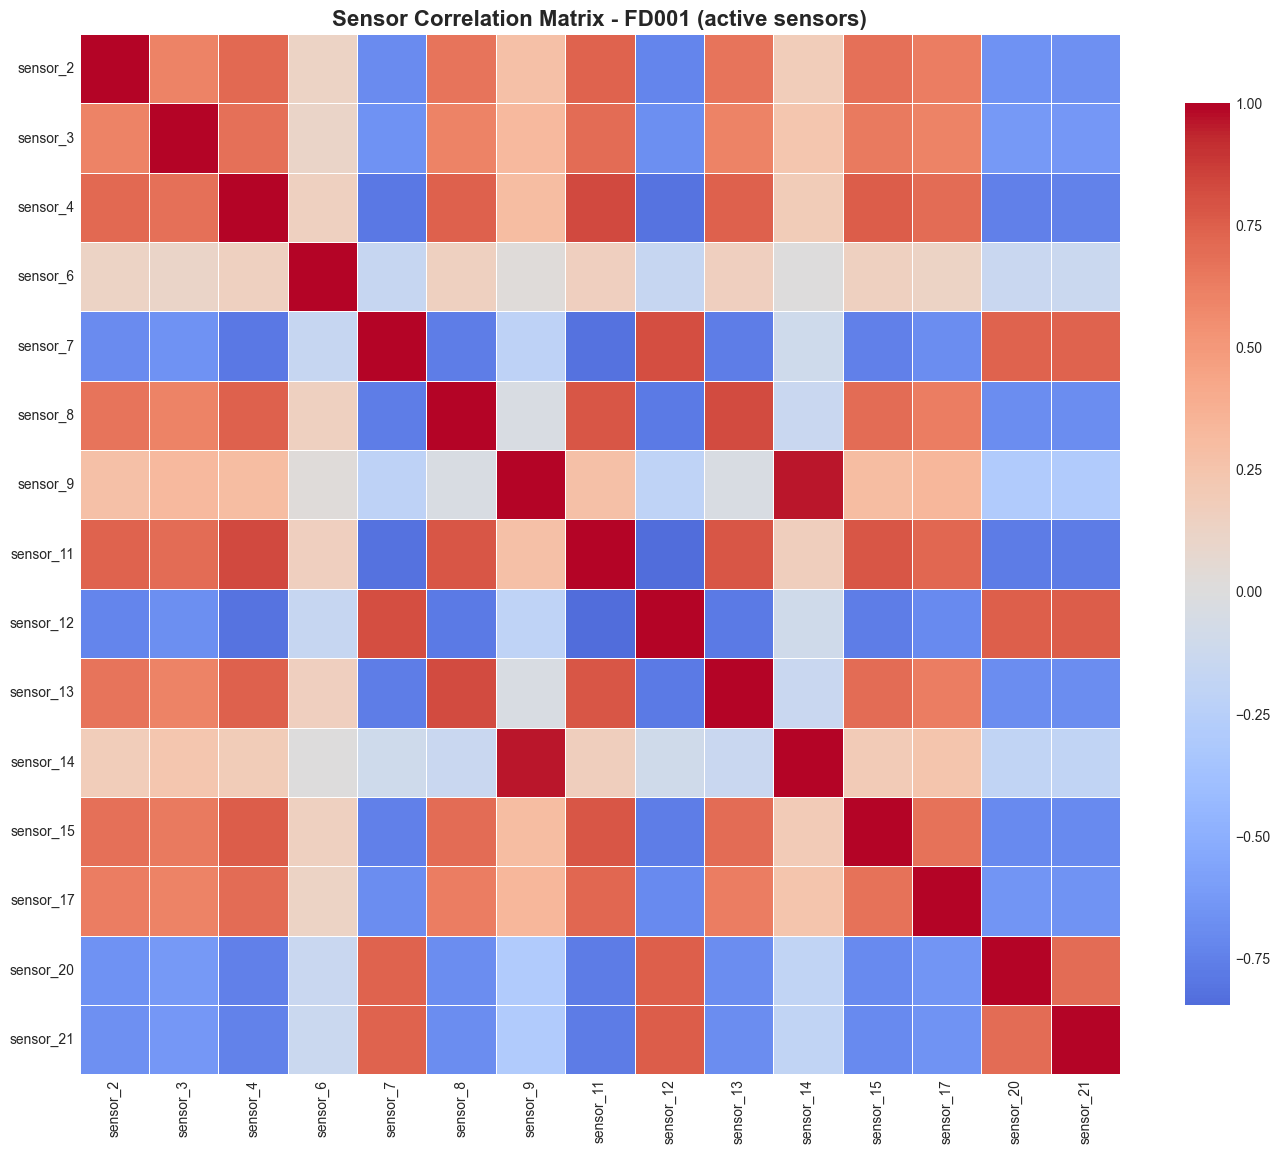

In [75]:
# Sensor correlation heatmap for FD001
df_fd001 = train_data['FD001']
sensor_cols = [col for col in df_fd001.columns if col.startswith('sensor_')]

# Remove constant sensors for correlation
constant_sensors = sensor_analysis['FD001']['constant_sensors']
active_sensors = [s for s in sensor_cols if s not in constant_sensors]

correlation_matrix = df_fd001[active_sensors].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Sensor Correlation Matrix - FD001 (active sensors)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. RUL Analysis (Remaining Useful Life)

### 5.1 RUL Distribution

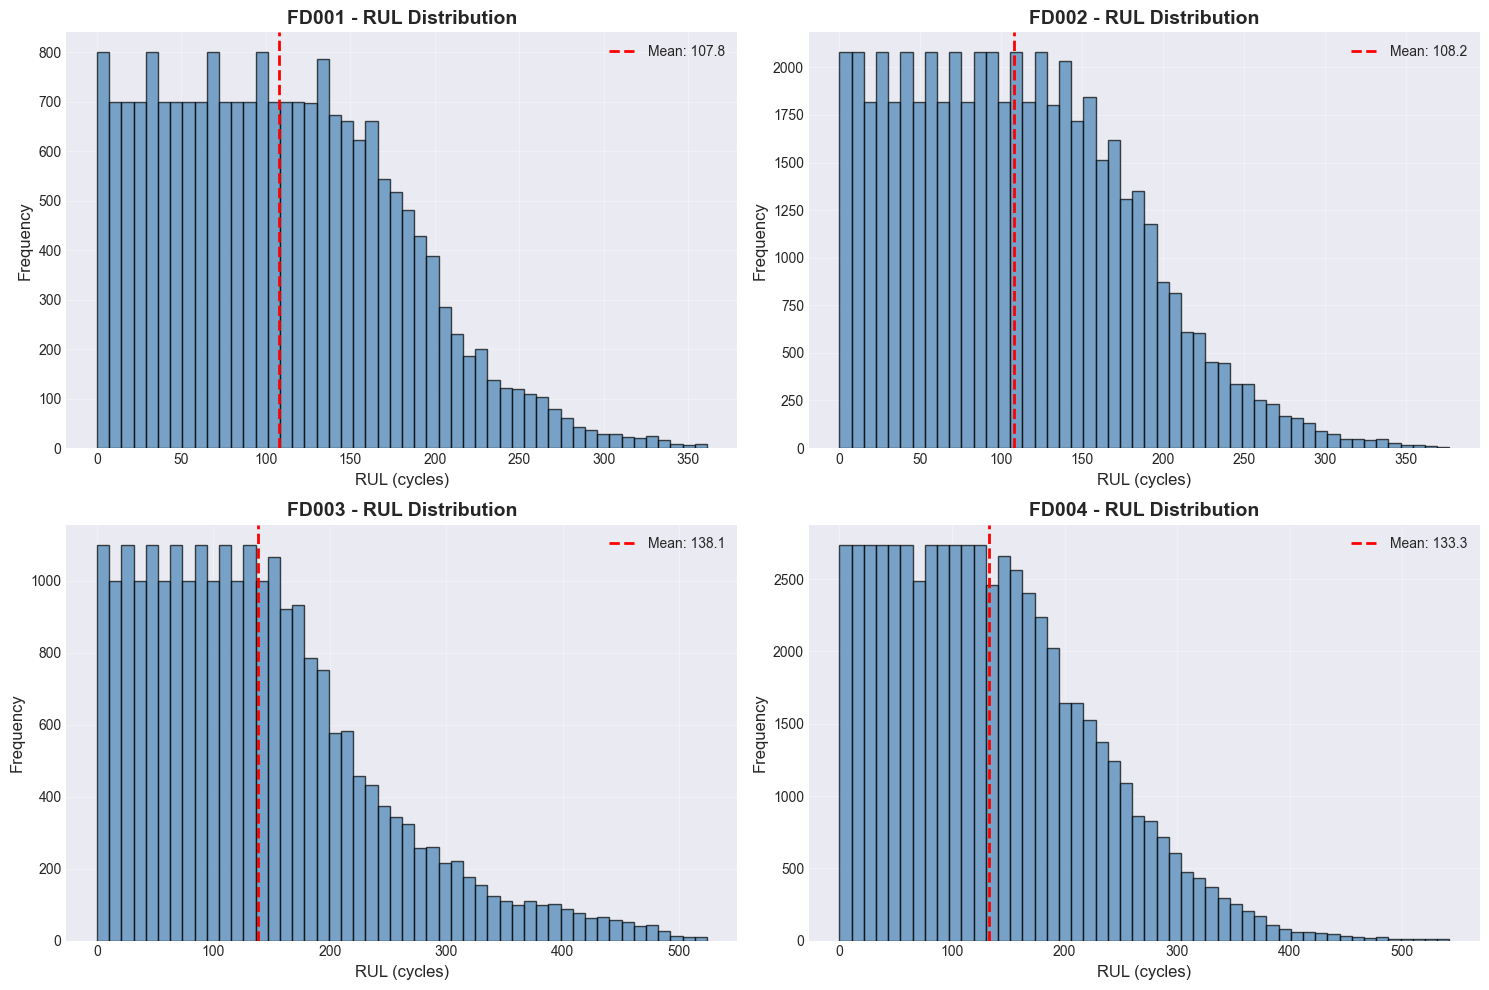


RUL STATISTICS:

FD001: Min=0, Max=361, Mean=107.81, Median=103.00
FD002: Min=0, Max=377, Mean=108.15, Median=103.00
FD003: Min=0, Max=524, Mean=138.08, Median=123.00
FD004: Min=0, Max=542, Mean=133.31, Median=122.00


In [76]:
# RUL distribution for all datasets
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (subset_name, df) in enumerate(train_data.items()):
    ax = axes[idx]
    
    df['RUL'].hist(bins=50, ax=ax, edgecolor='black', alpha=0.7, color='steelblue')
    
    ax.set_title(f"{subset_name} - RUL Distribution", fontsize=14, fontweight='bold')
    ax.set_xlabel("RUL (cycles)", fontsize=12)
    ax.set_ylabel("Frequency", fontsize=12)
    ax.axvline(df['RUL'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df['RUL'].mean():.1f}")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nRUL STATISTICS:\n")
for subset_name, df in train_data.items():
    print(f"{subset_name}: Min={df['RUL'].min()}, Max={df['RUL'].max()}, Mean={df['RUL'].mean():.2f}, Median={df['RUL'].median():.2f}")

## 6. Operating Conditions Analysis

### 6.1 Settings Distribution

In [77]:
def analyze_operating_conditions(data_dict):
    """
    Analyze operating conditions (settings).
    """
    results = {}
    
    for subset_name, df in data_dict.items():
        setting_cols = ['setting_1', 'setting_2', 'setting_3']
        
        # Unique settings combinations
        unique_conditions = df[setting_cols].drop_duplicates()
        
        results[subset_name] = {
            'unique_conditions': len(unique_conditions),
            'conditions_df': unique_conditions,
            'setting_stats': df[setting_cols].describe()
        }
    
    return results

operating_conditions = analyze_operating_conditions(train_data)

print("OPERATING CONDITIONS ANALYSIS\n")
print("=" * 70)
for subset, result in operating_conditions.items():
    info = dataset_info[subset]
    print(f"\n{subset}:")
    print(f"  Declared conditions: {info['conditions']}")
    print(f"  Unique combinations detected: {result['unique_conditions']}")
    print("\n  Settings statistics:")
    print(result['setting_stats'])

print("\n" + "=" * 70)

OPERATING CONDITIONS ANALYSIS


FD001:
  Declared conditions: ONE (Sea Level)
  Unique combinations detected: 1423

  Settings statistics:
       setting_1  setting_2  setting_3
count   20631.00   20631.00   20631.00
mean       -0.00       0.00     100.00
std         0.00       0.00       0.00
min        -0.01      -0.00     100.00
25%        -0.00      -0.00     100.00
50%         0.00       0.00     100.00
75%         0.00       0.00     100.00
max         0.01       0.00     100.00

FD002:
  Declared conditions: SIX
  Unique combinations detected: 9824

  Settings statistics:
       setting_1  setting_2  setting_3
count   53759.00   53759.00   53759.00
mean       24.00       0.57      94.05
std        14.75       0.31      14.24
min         0.00       0.00      60.00
25%        10.00       0.25     100.00
50%        25.00       0.70     100.00
75%        42.00       0.84     100.00
max        42.01       0.84     100.00

FD003:
  Declared conditions: ONE (Sea Level)
  Unique combina

## 7. Example Degradation Visualization

### 7.1 Sensor Degradation Pattern

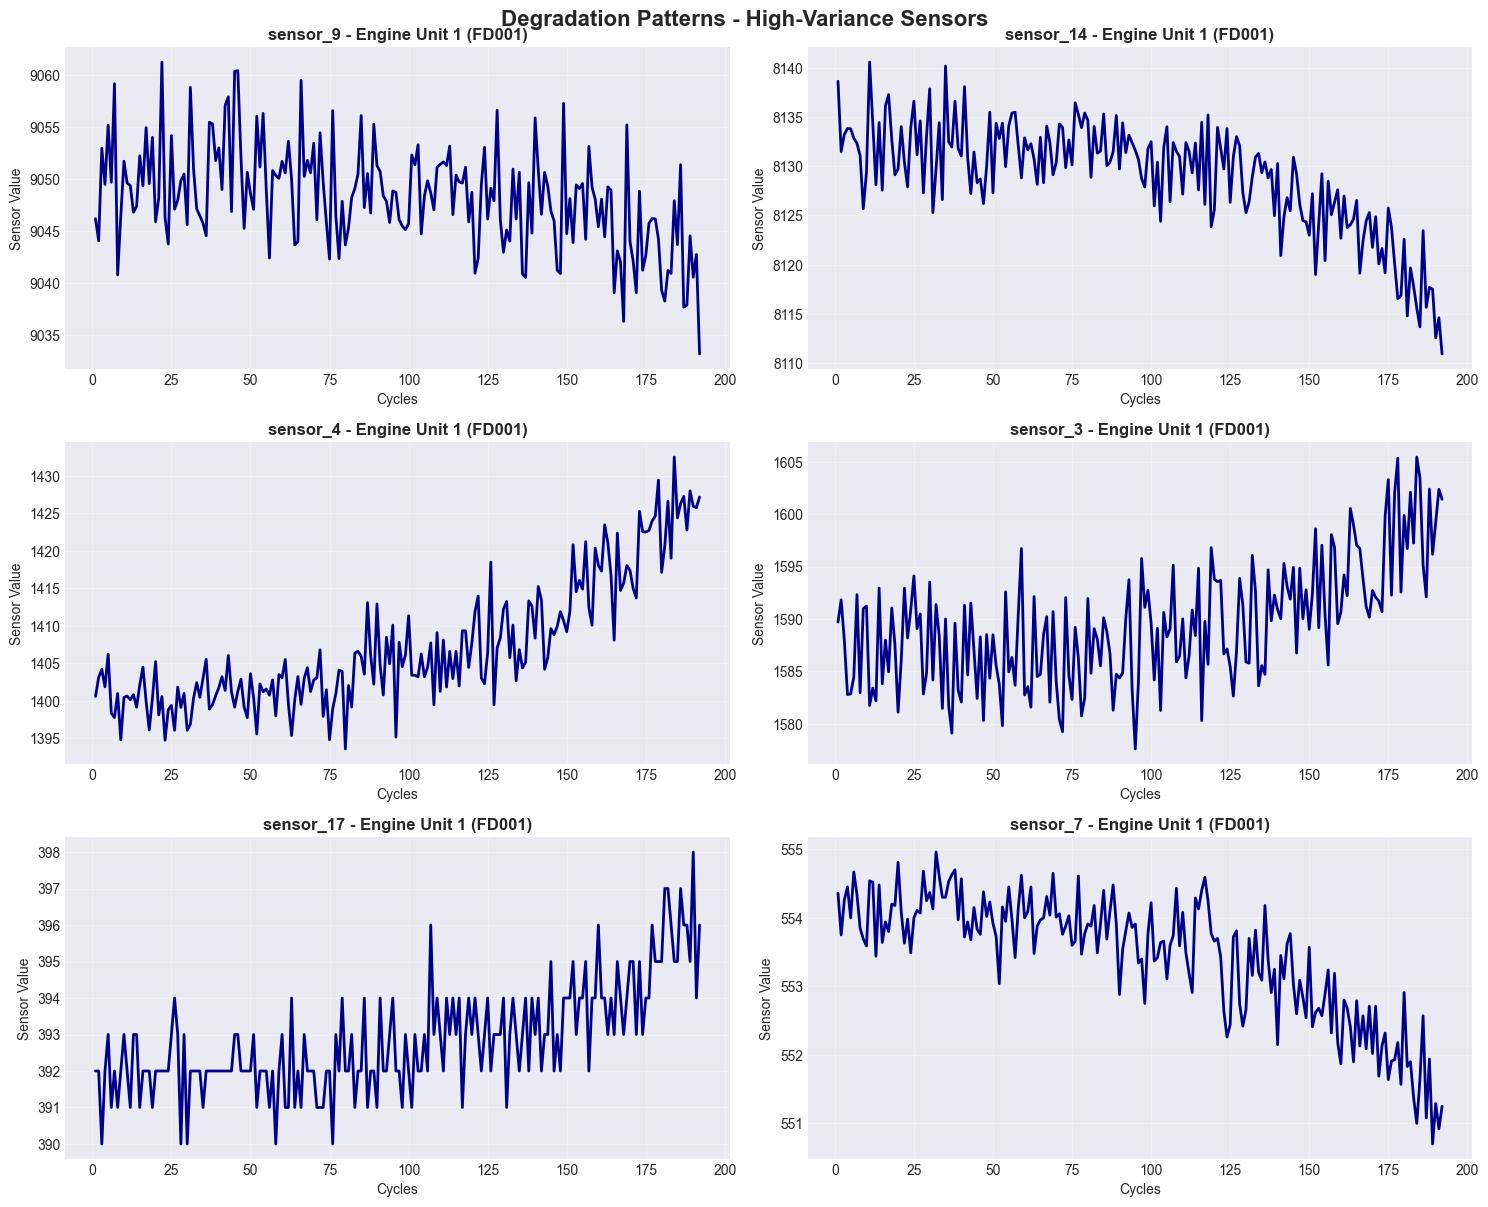

In [78]:
# Plot degradation of selected sensors for an example engine (FD001, unit 1)
df_example = train_data['FD001'][train_data['FD001']['unit'] == 1]

# Select sensors with high variance
high_variance_sensors = sensor_analysis['FD001']['stats'].nlargest(6, 'variance').index.tolist()

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, sensor in enumerate(high_variance_sensors):
    ax = axes[idx]
    
    ax.plot(df_example['time'], df_example[sensor], linewidth=2, color='darkblue')
    ax.set_title(f"{sensor} - Engine Unit 1 (FD001)", fontsize=12, fontweight='bold')
    ax.set_xlabel("Cycles", fontsize=10)
    ax.set_ylabel("Sensor Value", fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Degradation Patterns - High-Variance Sensors', fontsize=16, fontweight='bold', y=1.002)
plt.show()

### 7.2 RUL Degradation Curve

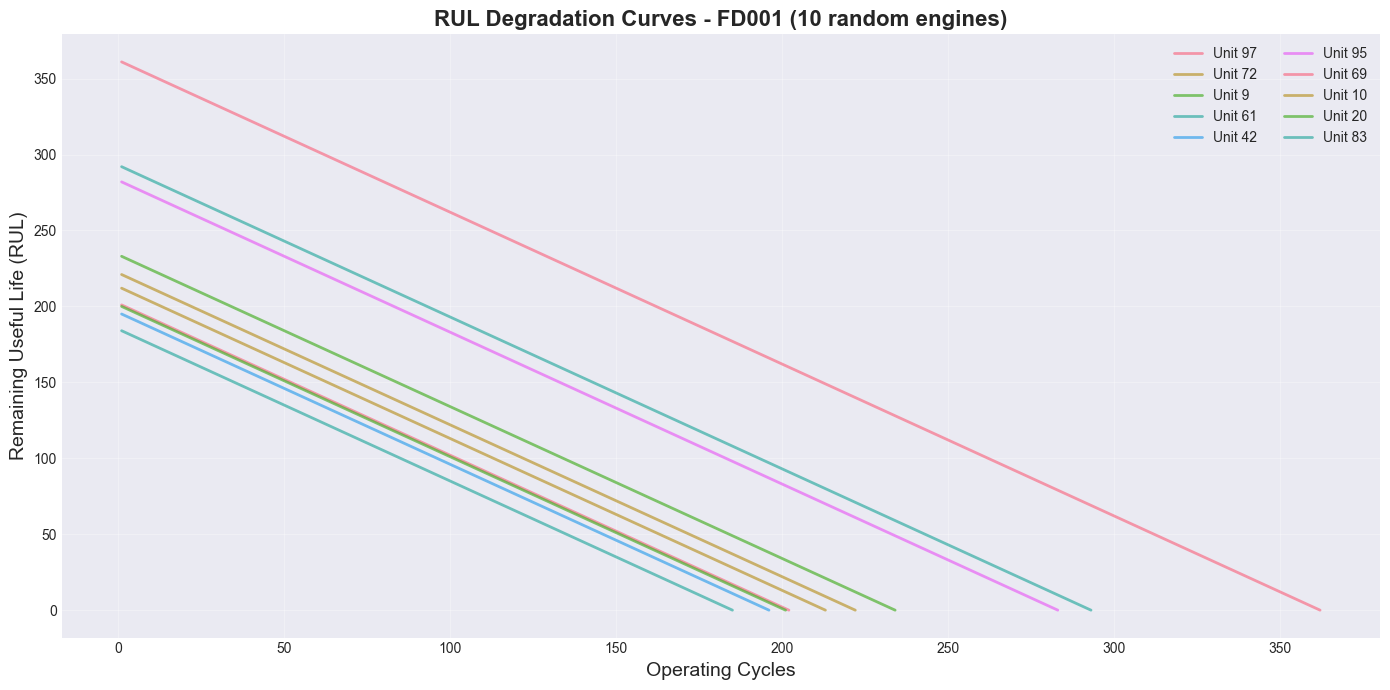

In [79]:
# Plot RUL decay for 10 random engines
df_fd001 = train_data['FD001']
rng = np.random.default_rng(42)
random_units = rng.choice(df_fd001['unit'].unique(), 10, replace=False)

plt.figure(figsize=(14, 7))

for unit in random_units:
    unit_data = df_fd001[df_fd001['unit'] == unit]
    plt.plot(unit_data['time'], unit_data['RUL'], linewidth=2, alpha=0.7, label=f"Unit {unit}")

plt.title('RUL Degradation Curves - FD001 (10 random engines)', fontsize=16, fontweight='bold')
plt.xlabel('Operating Cycles', fontsize=14)
plt.ylabel('Remaining Useful Life (RUL)', fontsize=14)
plt.legend(loc='upper right', ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Summary Report

### Data Quality Summary

In [80]:
print("\n" + "="*80)
print("FINAL REPORT - CMAPSS DATA QUALITY")
print("="*80 + "\n")

for subset in ['FD001', 'FD002', 'FD003', 'FD004']:
    if subset not in train_data:
        continue
        
    df = train_data[subset]
    
    print(f"\n{'='*80}")
    print(f"{subset}")
    print(f"{'='*80}")
    
    print("\nDATASET DIMENSIONS:")
    print(f"   - Total rows: {len(df):,}")
    print(f"   - Columns: {len(df.columns)}")
    print(f"   - Unique engines: {df['unit'].nunique()}")
    
    print("\nDATA QUALITY:")
    print(f"   - Missing values: {missing_analysis[subset]['missing_cells']} ({missing_analysis[subset]['missing_pct']:.4f}%)")
    print(f"   - Duplicates: {duplicate_analysis[subset]['key_duplicates']}")
    print(f"   - Consistent temporal sequences: {temporal_analysis[subset]['clean_units']}/{temporal_analysis[subset]['total_units']}")
    
    print("\nLIFECYCLE:")
    lc = lifecycle_analysis[subset]
    print(f"   - Min: {lc['min']} cycles")
    print(f"   - Max: {lc['max']} cycles")
    print(f"   - Mean: {lc['mean']:.2f} cycles")
    print(f"   - Median: {lc['median']:.2f} cycles")
    
    print("\nSENSORS:")
    sa = sensor_analysis[subset]
    print(f"   - Total sensors: {sa['total_sensors']}")
    print(f"   - Constant sensors: {len(sa['constant_sensors'])}")
    print(f"   - Active sensors: {sa['total_sensors'] - len(sa['constant_sensors'])}")
    
    print("\nOPERATING CONDITIONS:")
    oc = operating_conditions[subset]
    print(f"   - Unique combinations: {oc['unique_conditions']}")
    
    print("\nRUL:")
    print(f"   - Min: {df['RUL'].min()}")
    print(f"   - Max: {df['RUL'].max()}")
    print(f"   - Mean: {df['RUL'].mean():.2f}")
    
    # Final verdict
    issues = []
    if missing_analysis[subset]['missing_cells'] > 0:
        issues.append("Missing values")
    if duplicate_analysis[subset]['key_duplicates'] > 0:
        issues.append("Duplicates")
    if temporal_analysis[subset]['clean_units'] < temporal_analysis[subset]['total_units']:
        issues.append("Temporal issues")
    
    print("\nVERDICT:")
    if not issues:
        print("   Dataset CLEAN and READY for modeling")
    else:
        print(f"   Issues detected: {', '.join(issues)}")
        print("   Requires preprocessing")


FINAL REPORT - CMAPSS DATA QUALITY


FD001

DATASET DIMENSIONS:
   - Total rows: 20,631
   - Columns: 27
   - Unique engines: 100

DATA QUALITY:
   - Missing values: 0 (0.0000%)
   - Duplicates: 0
   - Consistent temporal sequences: 100/100

LIFECYCLE:
   - Min: 128 cycles
   - Max: 362 cycles
   - Mean: 206.31 cycles
   - Median: 199.00 cycles

SENSORS:
   - Total sensors: 21
   - Constant sensors: 6
   - Active sensors: 15

OPERATING CONDITIONS:
   - Unique combinations: 1423

RUL:
   - Min: 0
   - Max: 361
   - Mean: 107.81

VERDICT:
   Dataset CLEAN and READY for modeling

FD002

DATASET DIMENSIONS:
   - Total rows: 53,759
   - Columns: 27
   - Unique engines: 260

DATA QUALITY:
   - Missing values: 0 (0.0000%)
   - Duplicates: 0
   - Consistent temporal sequences: 260/260

LIFECYCLE:
   - Min: 128 cycles
   - Max: 378 cycles
   - Mean: 206.77 cycles
   - Median: 199.00 cycles

SENSORS:
   - Total sensors: 21
   - Constant sensors: 0
   - Active sensors: 21

OPERATING CONDITIONS:
